<a href="https://colab.research.google.com/github/Thinujan-Thillaiselvan/ME320/blob/main/Competency_assessment_quiz_on_First_Approximation_of_a_Vibratory_System_e21411.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

question 5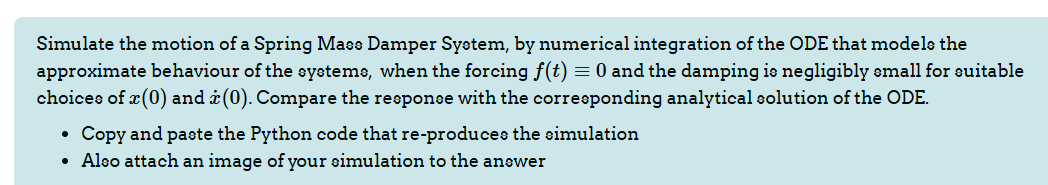

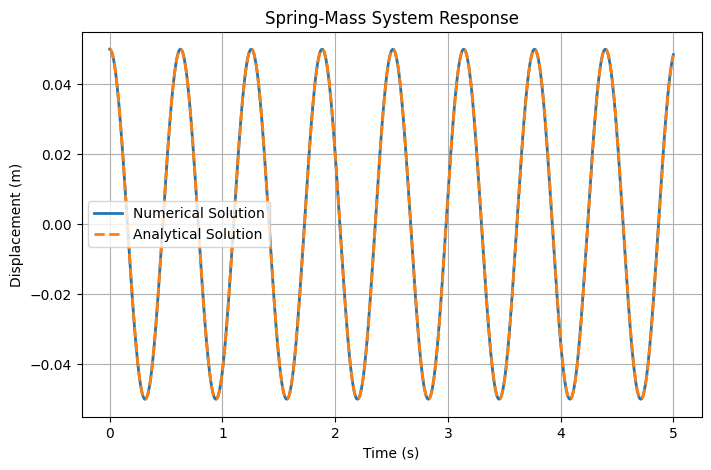

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp



# System parameters

M = 1.0          # Mass (kg)

K = 100.0        # Spring stiffness (N/m)

C = 0.0          # Negligible damping



# Natural frequency

wn = np.sqrt(K / M)



# Initial conditions

x0 = 0.05        # Initial displacement (m)

v0 = 0.0         # Initial velocity (m/s)



# Equation of motion

def spring_mass_system(t, y):

    x, v = y

    dxdt = v

    dvdt = -(K / M) * x

    return [dxdt, dvdt]



# Time interval

t = np.linspace(0, 5, 1000)



# Numerical solution

solution = solve_ivp(

    spring_mass_system,

    [0, 5],

    [x0, v0],

    t_eval=t

)



# Analytical solution

x_analytical = x0 * np.cos(wn * t) + (v0 / wn) * np.sin(wn * t)



# Plot

plt.figure(figsize=(8,5))

plt.plot(t, solution.y[0], label="Numerical Solution", linewidth=2)

plt.plot(t, x_analytical, '--', label="Analytical Solution", linewidth=2)



plt.xlabel("Time (s)")

plt.ylabel("Displacement (m)")

plt.title("Spring-Mass System Response")

plt.grid(True)

plt.legend()



plt.show()

question 7
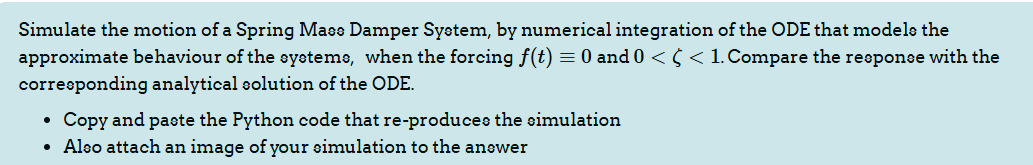

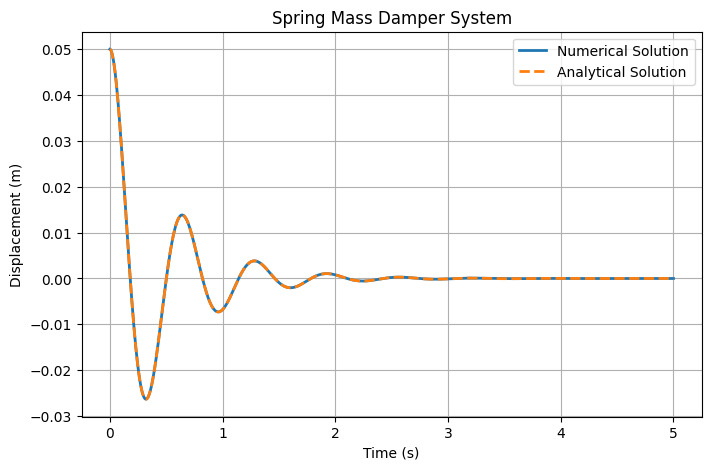

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# System parameters
M = 1.0          # Mass (kg)
K = 100.0        # Spring stiffness (N/m)
zeta = 0.2       # Damping ratio (0 < zeta < 1)

# Natural frequency
wn = np.sqrt(K / M)

# Damping coefficient
C = 2 * zeta * wn * M

# Initial conditions
x0 = 0.05        # Initial displacement (m)
v0 = 0.0         # Initial velocity (m/s)

# Equation of motion
def spring_mass_damper(t, y):
    x, v = y
    dxdt = v
    dvdt = -(C/M)*v - (K/M)*x
    return [dxdt, dvdt]

# Time span
t = np.linspace(0, 5, 1000)

# Numerical solution
sol = solve_ivp(
    spring_mass_damper,
    [0, 5],
    [x0, v0],
    t_eval=t
)

# Damped natural frequency
wd = wn * np.sqrt(1 - zeta**2)

# Analytical solution
x_analytical = np.exp(-zeta*wn*t) * (
    x0*np.cos(wd*t) +
    ((v0 + zeta*wn*x0)/wd)*np.sin(wd*t)
)

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, sol.y[0], label='Numerical Solution', linewidth=2)
plt.plot(t, x_analytical, '--', label='Analytical Solution', linewidth=2)

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Spring Mass Damper System')
plt.grid(True)
plt.legend()

plt.show()

question 9
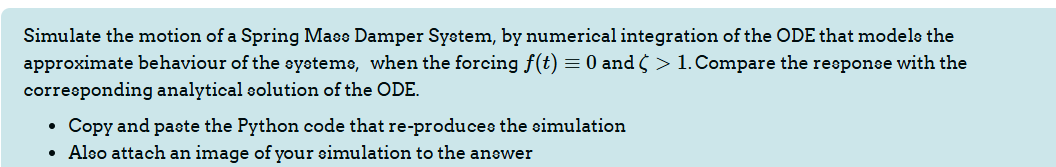

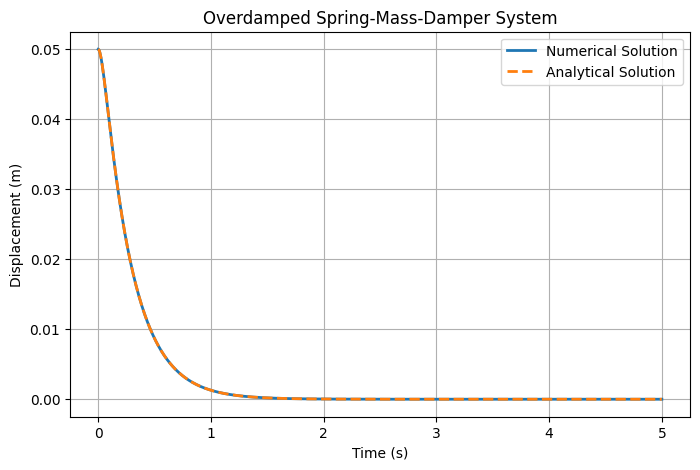

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# System parameters
M = 1.0          # Mass (kg)
K = 100.0        # Spring stiffness (N/m)
zeta = 1.5       # Damping ratio (zeta > 1)

# Natural frequency
wn = np.sqrt(K/M)

# Damping coefficient
C = 2*zeta*wn*M

# Initial conditions
x0 = 0.05        # Initial displacement (m)
v0 = 0.0         # Initial velocity (m/s)

# Equation of motion
def spring_mass_damper(t, y):
    x, v = y
    dxdt = v
    dvdt = -(C/M)*v - (K/M)*x
    return [dxdt, dvdt]

# Time interval
t = np.linspace(0, 5, 1000)

# Numerical solution
sol = solve_ivp(
    spring_mass_damper,
    [0, 5],
    [x0, v0],
    t_eval=t
)

# Analytical solution
lambda1 = wn*(zeta - np.sqrt(zeta**2 - 1))
lambda2 = wn*(zeta + np.sqrt(zeta**2 - 1))

A = (v0 + lambda2*x0)/(lambda2 - lambda1)
B = x0 - A

x_analytical = A*np.exp(-lambda1*t) + B*np.exp(-lambda2*t)

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, sol.y[0], label='Numerical Solution', linewidth=2)
plt.plot(t, x_analytical, '--', label='Analytical Solution', linewidth=2)

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Overdamped Spring-Mass-Damper System')
plt.grid(True)
plt.legend()

plt.show()

question 10
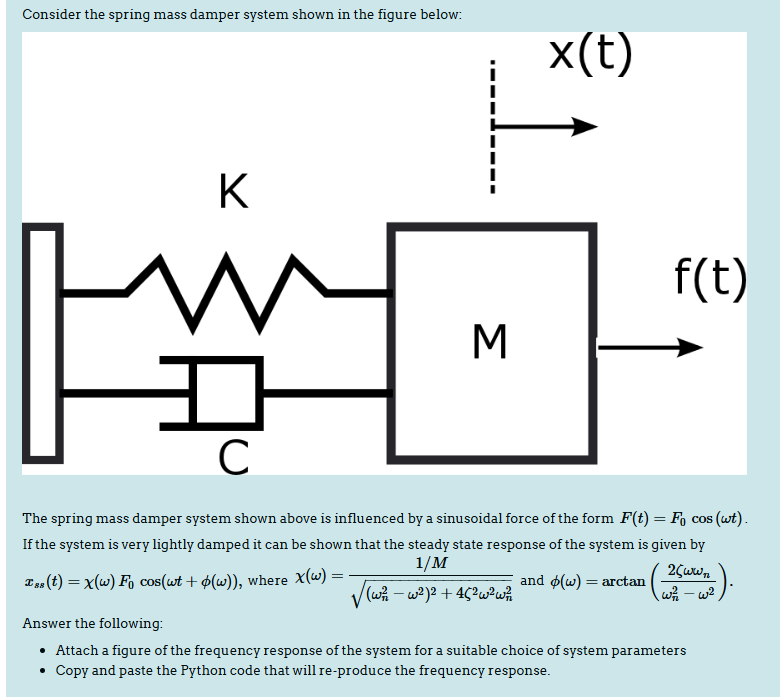

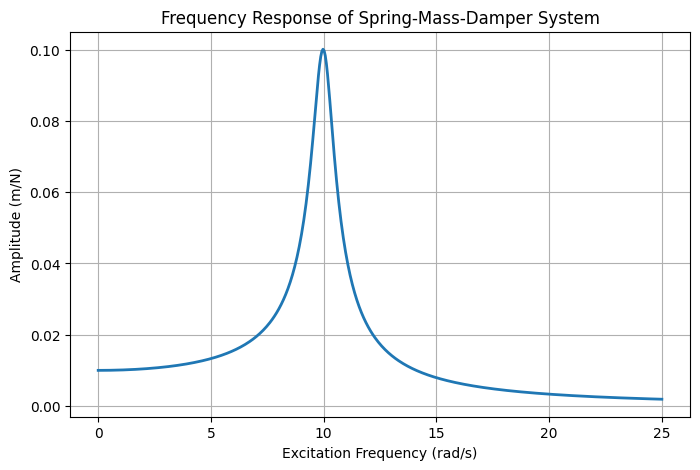

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# System parameters
M = 1.0          # Mass (kg)
K = 100.0        # Spring stiffness (N/m)
zeta = 0.05      # Light damping
F0 = 1.0         # Force amplitude (N)

# Natural frequency
wn = np.sqrt(K/M)

# Excitation frequency
omega = np.linspace(0,25,500)

# Frequency response amplitude
X = (F0/M)/np.sqrt((wn**2-omega**2)**2 + (2*zeta*wn*omega)**2)

# Phase angle
phi = np.arctan2(2*zeta*wn*omega,(wn**2-omega**2))

# Plot Frequency Response
plt.figure(figsize=(8,5))
plt.plot(omega,X,linewidth=2)

plt.xlabel("Excitation Frequency (rad/s)")
plt.ylabel("Amplitude (m/N)")
plt.title("Frequency Response of Spring-Mass-Damper System")
plt.grid(True)

plt.show()